<a href="https://colab.research.google.com/github/abdulabc23/Netflix-Data-Analysis/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Netflix movie Data Analysis



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("import success")

import success


In [ ]:
from google.colab import drive
drive.mount('/content/drvie')

Mounted at /content/drvie


In [ ]:
file_path = '/content/drvie/MyDrive/Netflix/netflix_titles.csv'
df = pd.read_csv(file_path)

In [ ]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [ ]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
(8807, 12)


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


#**Handle Missing Values**

In [36]:
# Filling Null values.
df['country'] = df['country'].fillna("Unknow" )
df['director'] = df['director'].fillna("Unknow")
df['cast'] = df['cast'].fillna("Unknow")
df["rating"] = df["rating"].fillna("Not Rated")

# Droping Null values
df.dropna(subset = ['duration' , 'date_added'] , inplace=True)
df.reset_index(drop=True , inplace=True)

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')


In [ ]:
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month

In [ ]:
df.drop(columns=['description'] , inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

#Feature Engineering

In [ ]:
# extracting main country from country , listed_in
df['country'] = df['country'].str.split(',')
df = df.explode('country')
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')


In [ ]:
df["Duration_number"] = df['duration'].str.extract(r'(\d+)').astype(int)
df["Duration_type"] = df['duration'].str.extract('(min|Seasons)')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,added_year,added_month,Duration_number,Duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknow,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90,min
1,s2,TV Show,Blood & Water,Unknow,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,2021,9,2,Seasons
1,s2,TV Show,Blood & Water,Unknow,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,2021,9,2,Seasons
1,s2,TV Show,Blood & Water,Unknow,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,2021,9,2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknow,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,2021,9,1,NaN


#**EDA**

Which country produces most netflix content

/tmp/ipykernel_794/786199412.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = most_content.values , y = most_content.index , palette='viridis')


Text(0.5, 1.0, 'Top 10 countries producess more content')

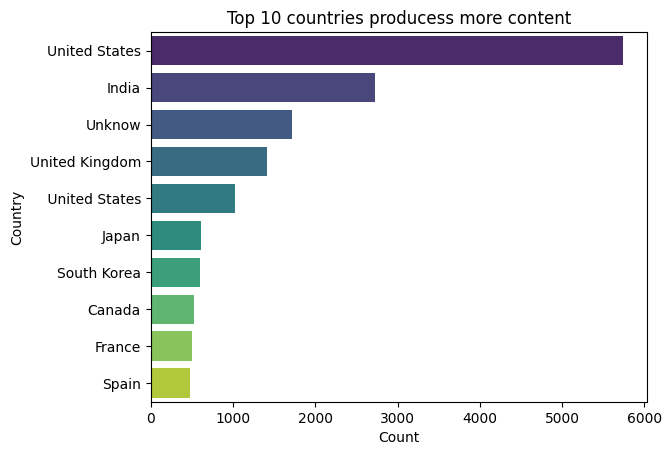

In [ ]:
most_content = df['country'].value_counts().sort_values(ascending=False).head(10)
sns.barplot(x = most_content.values , y = most_content.index , palette='viridis')
plt.xlabel('Count')
plt.ylabel('Country')
plt.title("Top 10 countries producess more content")

How many movies and Tc Shows are on netflix

/tmp/ipykernel_794/1215738207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df , x='type' , palette='magma')


Text(0.5, 1.0, 'Distribution of Movie and TV Shows')

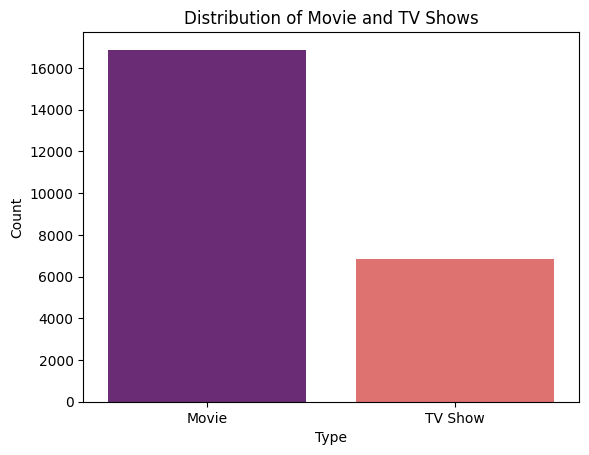

In [ ]:
type_count = df['type'].value_counts()
sns.countplot(data=df , x='type' , palette='magma')
plt.xlabel('Type')
plt.ylabel('Count')
plt.title("Distribution of Movie and TV Shows")

Movie


Text(0.5, 1.0, 'Distribution of TV Shows and Movies')

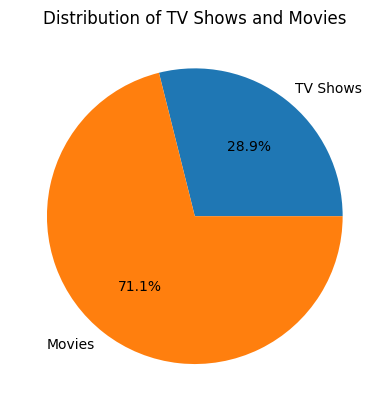

In [ ]:
# Type percentage
total_entries = df['type'].count()
entries_values = df['type'].value_counts()
print(entries_values.index[0])
tv_percentage = (entries_values.values[1]*100)/total_entries
movie_percentage = (entries_values.values[0]*100)/total_entries
plt.pie([tv_percentage, movie_percentage], labels=['TV Shows', 'Movies'], autopct='%1.1f%%')
plt.title('Distribution of TV Shows and Movies')


#**Genre**

what is the most common genre on the Netflix

In [ ]:
most_comon_genre=df['listed_in'].value_counts().sort_values(ascending=False).head(1)
print(f"Most common genre is {most_comon_genre}")

Most common genre is listed_in
International Movies    3366
Name: count, dtype: int64


Top Genre on Netflix

/tmp/ipykernel_794/245157262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = genre_count.values , y = genre_count.index , palette='viridis')


Text(0.5, 1.0, 'Top 10 Genre on Netflix')

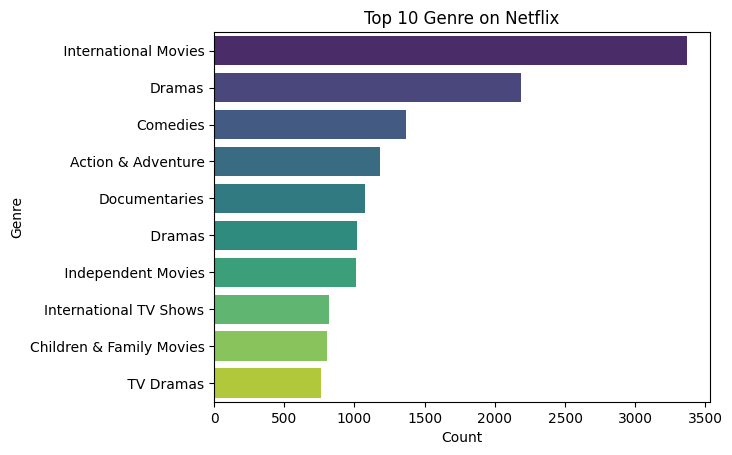

In [ ]:
genre_count=df['listed_in'].value_counts().sort_values(ascending=False).head(10)
sns.barplot(x = genre_count.values , y = genre_count.index , palette='viridis')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.title("Top 10 Genre on Netflix")

least 10 genre showed on netflix

/tmp/ipykernel_794/1457159733.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = genre_count.values , y = genre_count.index , palette='viridis')


<Axes: ylabel='listed_in'>

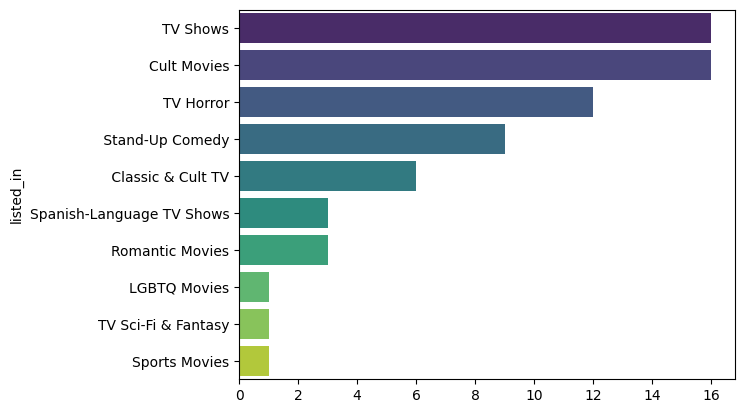

In [ ]:
genre_count=df['listed_in'].value_counts().sort_values(ascending=False).tail(10)
sns.barplot(x = genre_count.values , y = genre_count.index , palette='viridis')

#**Content Growth Analysis.**

How many titles were added to Netflix each year?

/tmp/ipykernel_794/2431432342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_stats.index, y=yearly_stats.values, palette='viridis')


Text(0, 0.5, 'Year')

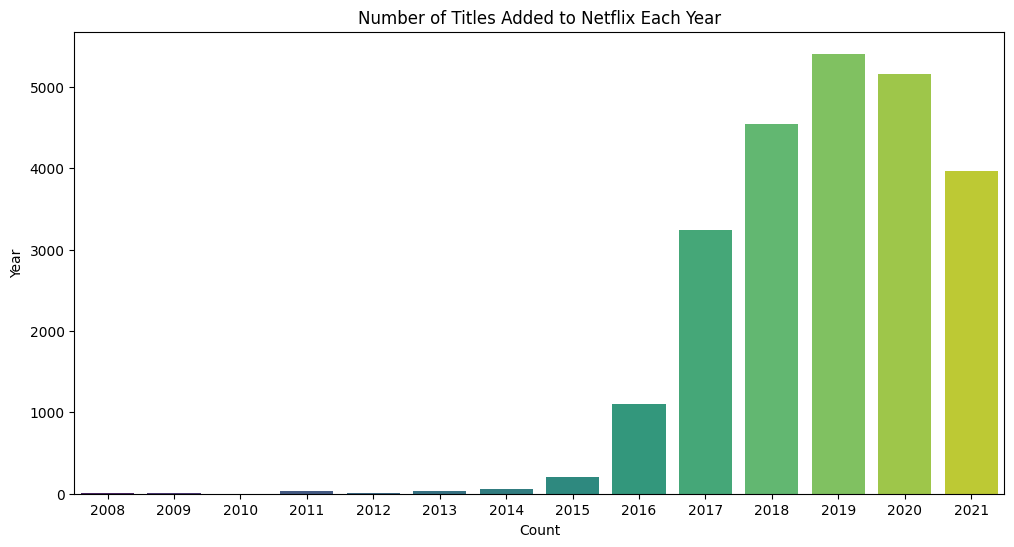

In [ ]:
plt.figure(figsize=(12,6))
yearly_stats = df.groupby('added_year')['title'].count().sort_values(ascending=False)
sns.barplot(x=yearly_stats.index, y=yearly_stats.values, palette='viridis')
plt.title('Number of Titles Added to Netflix Each Year')
plt.xlabel('Count')
plt.ylabel('Year')

year 2019 is the year which highest content on netflix.

In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,added_year,added_month,Duration_number,Duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknow,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90,min
1,s2,TV Show,Blood & Water,Unknow,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,2021,9,2,Seasons


In [ ]:
title_by_month = pd.pivot_table(df,values="title" , index="added_month" , columns="added_year" , aggfunc="count")
print(title_by_month)

added_year   2008  2009  2010  2011  2012  2013  2014  2015   2016   2017  \
added_month                                                                 
1             3.0   NaN   NaN   NaN   NaN   NaN   7.0   1.0  129.0  204.0   
2             1.0   NaN   NaN   NaN   1.0   NaN   6.0  22.0   47.0  226.0   
3             NaN   NaN   NaN   NaN   NaN   6.0   NaN   6.0   38.0  340.0   
4             NaN   NaN   NaN   NaN   NaN   NaN   3.0  16.0   54.0  226.0   
5             NaN   2.0   NaN   6.0   NaN   NaN   NaN  11.0   38.0  239.0   
6             NaN   NaN   NaN   NaN   NaN   NaN   1.0  16.0   43.0  284.0   
7             NaN   NaN   NaN   NaN   NaN   NaN   2.0  15.0   81.0  202.0   
8             NaN   NaN   NaN   NaN   NaN   3.0   3.0   5.0   72.0  334.0   
9             NaN   NaN   NaN   9.0   NaN   7.0   1.0  23.0  113.0  317.0   
10            NaN   NaN   NaN  14.0   NaN   5.0   5.0  39.0  138.0  352.0   
11            NaN   1.0   2.0   NaN   2.0   2.0  13.0   6.0  101.0  195.0   

/tmp/ipykernel_794/1571174411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = rating_category.values , y = rating_category.index , palette='viridis')


Text(0.5, 1.0, 'Top 7 Rating on Netflix')

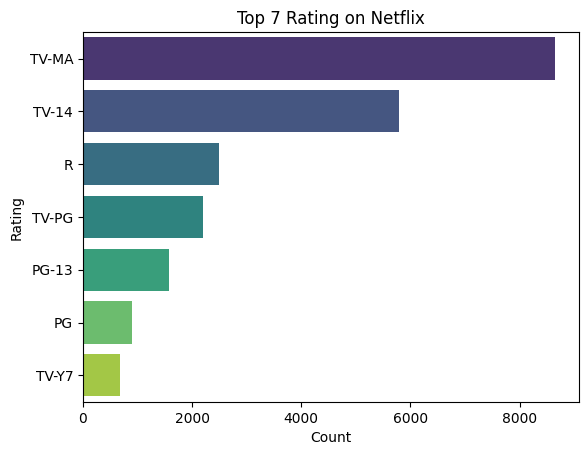

In [ ]:
rating_category = df["rating"].value_counts().sort_values(ascending=False).head(7)
sns.barplot(x = rating_category.values , y = rating_category.index , palette='viridis')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.title("Top 7 Rating on Netflix")

In [ ]:
movie_duration = df[df['Duration_type']=="min"]['Duration_number'].mean()
print(f"Average movie duration is {movie_duration}")

Average movie duration is 103.8949644549763


In [ ]:
columns_toview=["show_id",'type','title','Duration_number','added_year']
long_duration_movies = df[df['Duration_type']=="min"][columns_toview].sort_values(by='Duration_number', ascending=False).head(10)
print(long_duration_movies)

     show_id   type                        title  Duration_number  added_year
4253   s4254  Movie   Black Mirror: Bandersnatch              312        2018
4253   s4254  Movie   Black Mirror: Bandersnatch              312        2018
4253   s4254  Movie   Black Mirror: Bandersnatch              312        2018
717     s718  Movie  Headspace: Unwind Your Mind              273        2021
2491   s2492  Movie       The School of Mischief              253        2020
2491   s2492  Movie       The School of Mischief              253        2020
2491   s2492  Movie       The School of Mischief              253        2020
2487   s2488  Movie               No Longer kids              237        2020
2487   s2488  Movie               No Longer kids              237        2020
2487   s2488  Movie               No Longer kids              237        2020


which Tv show has the most seasons

In [ ]:
columns_displayed = ['show_id','type','title','Duration_number','added_year','listed_in']
most_seasons = df[df['Duration_type']=='Seasons'][columns_displayed].sort_values(by='Duration_number', ascending=False).head(1)
print(most_seasons)

    show_id     type           title  Duration_number  added_year  \
548    s549  TV Show  Grey's Anatomy               17        2021   

             listed_in  
548  Romantic TV Shows  


#Directors Analysis

Director most displayed on netflix.
top 10 directors with number of titles



In [ ]:
directors = df['director'].value_counts().head(10)
print(directors)

director
Unknow                 6547
Youssef Chahine          46
Cathy Garcia-Molina      37
Martin Scorsese          36
Lars von Trier           33
Steven Spielberg         32
Olivier Assayas          30
Tom Hooper               30
Suhas Kadav              29
Don Michael Paul         29
Name: count, dtype: int64


#Actors Analysis

Which Actor Appears most on netflix and top 10 actors.

In [ ]:
acotrs = df['cast'].value_counts().head(10)
print(acotrs)

cast
Unknow                                                                                                                                                                                          1848
David Attenborough                                                                                                                                                                                98
John Sparkes, Justin Fletcher, Kate Harbour, Richard Webber, Jo Allen                                                                                                                             24
Robin Wright, Harvey Keitel, Jon Hamm, Paul Giamatti, Kodi Smit-McPhee, Danny Huston, Sami Gayle, Michael Stahl-David, Michael Landes, Sarah Shahi                                                21
Saara Chaudry, Soma Chhaya, Ali Badshah, Soma Bhatia, Shaista Latif, Laara Sadiq, Kawa Ada, Noorin Gulamgaus                                                                                      21
Samuel Wes

#Main Analysis

Relationship between Genre and Rating.

<Axes: xlabel='rating', ylabel='listed_in'>

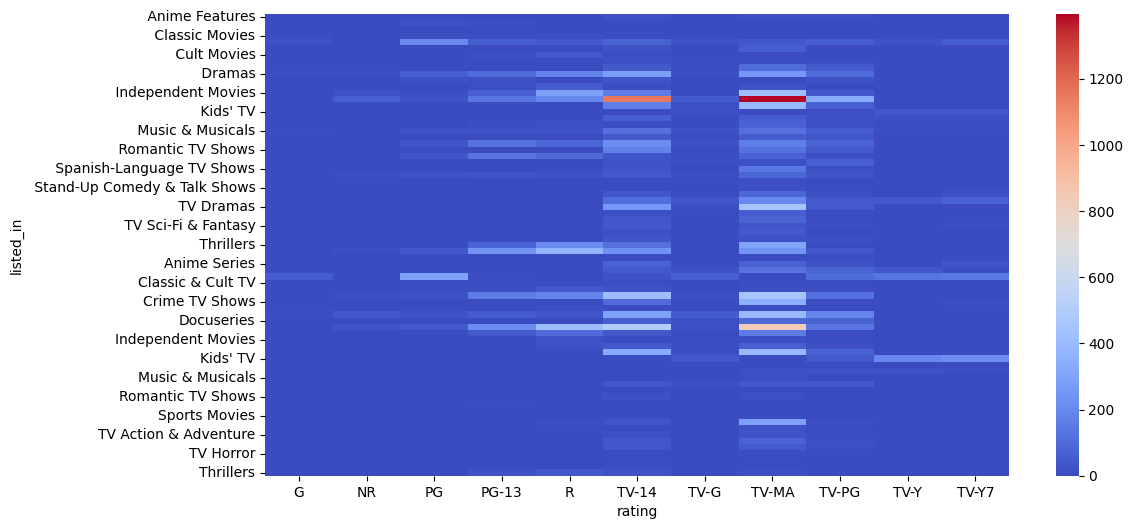

In [ ]:
figure = plt.figure(figsize=(12,6))
ratings = df['rating'].value_counts()
filtered_ratings = ratings[ratings>100].index
filtered_dataset = df[df['rating'].isin(filtered_ratings)]
genre_rating= filtered_dataset.groupby(['listed_in','rating']).size().unstack().fillna(0)
sns.heatmap(genre_rating , cmap="coolwarm")

Which country produces the most TV Shows vs Movies?

<Axes: xlabel='type', ylabel='country'>

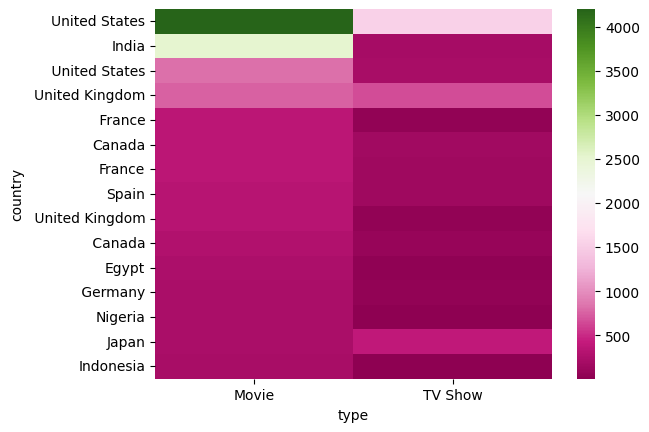

In [ ]:
country_wise_movies = df.groupby(['country','type']).size().unstack().fillna(0)
country_wise_movies = country_wise_movies.drop('Unknow').sort_values(by='Movie', ascending=False).head(15)
sns.heatmap(country_wise_movies, cmap='PiYG')

Which genre is most popular for Movies vs TV Shows?

In [ ]:
movies = df[df['type']=='Movie']
tv_shows = df[df['type']=='TV Show']

/tmp/ipykernel_794/2083092070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = movies_count.values , y = movies_count.index , palette='viridis')


<Axes: ylabel='listed_in'>

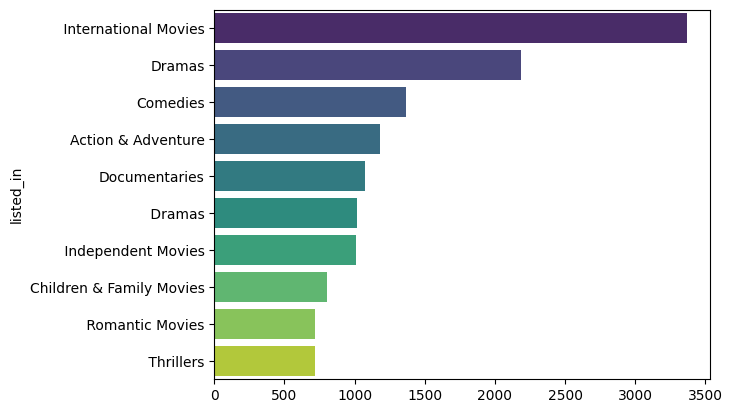

In [ ]:
movies_count = movies['listed_in'].value_counts().sort_values(ascending=False).head(10)
sns.barplot(x = movies_count.values , y = movies_count.index , palette='viridis')

/tmp/ipykernel_794/172413269.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = tv_shows_count.values , y = tv_shows_count.index , palette='viridis')


<Axes: ylabel='listed_in'>

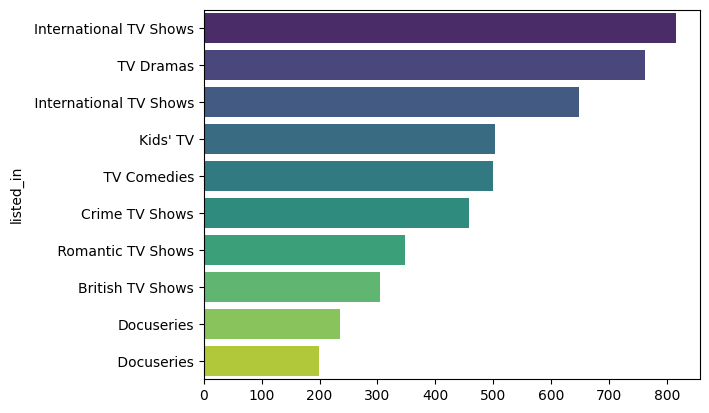

In [ ]:
tv_shows_count = tv_shows['listed_in'].value_counts().sort_values(ascending=False).head(10)
sns.barplot(x = tv_shows_count.values , y = tv_shows_count.index , palette='viridis')